Deliverabel 1

Viktor M.L hedman og Adrian N. Vangen

Importent imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import requests



Colekting the metrolagical data for 2025

In [10]:
with open('Frost_Met_ID.txt', 'r') as f:
    Frost_Met_ID = f.readlines()[0].strip().split(':')[1]
    

endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

request_temperature = requests.get(endpoint, params=parameters, auth=(Frost_Met_ID, ''))

json=request_temperature.json()

if request_temperature.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % request_temperature.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

df = pd.DataFrame()
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    df = pd.concat([df, row])

df = df.reset_index()

df.head(5)

Data retrieved from frost.met.no!


,index,elementId,value,unit,level,timeOffset,timeResolution,timeSeriesId,performanceCategory,exposureCategory,qualityCode,referenceTime,sourceId
0,0,mean(air_temperature P1D),-5.2,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT0H,P1D,0,C,1,0.0,2025-01-01T00:00:00.000Z,SN17850:0
1,1,mean(air_temperature P1D),-2.8,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT6H,P1D,0,C,1,NaN,2025-01-01T00:00:00.000Z,SN17850:0
2,0,mean(air_temperature P1D),-11.5,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT0H,P1D,0,C,1,0.0,2025-01-02T00:00:00.000Z,SN17850:0
3,1,mean(air_temperature P1D),-7.2,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT6H,P1D,0,C,1,NaN,2025-01-02T00:00:00.000Z,SN17850:0
4,0,mean(air_temperature P1D),-8.9,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT0H,P1D,0,C,1,0.0,2025-01-03T00:00:00.000Z,SN17850:0


Plots

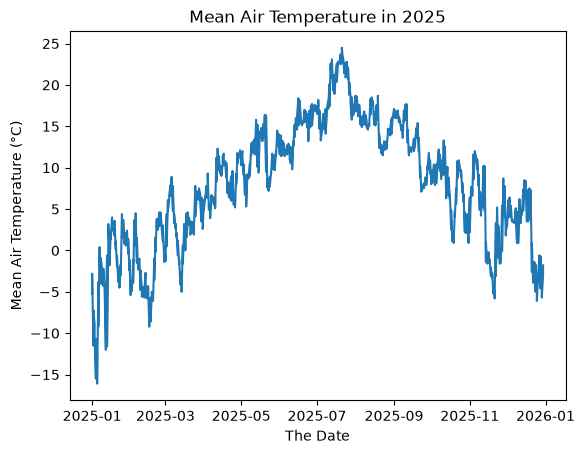

In [11]:
df['referenceTime'] = pd.to_datetime(df['referenceTime'])

plt.plot(df['referenceTime'], df['value'])
plt.title('Mean Air Temperature in 2025')
plt.xlabel('The Date')
plt.ylabel('Mean Air Temperature (°C)') 
plt.show()